In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Week 4 Business Churn Analysis Started")

Week 4 Business Churn Analysis Started


In [2]:
df = pd.read_csv(
    "../../data/processed/telco_person3_week1_cleaned_encoded.csv"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset loaded successfully!
Shape: (7043, 31)
Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


Basic business metrics

In [3]:
total_customers = len(df)

churned_customers = df["Churn"].sum()

churn_rate = (churned_customers / total_customers) * 100

average_monthly_charges = df["MonthlyCharges"].mean()

average_tenure = df["tenure"].mean()

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", round(churn_rate, 2), "%")
print("Average Monthly Charges:", round(average_monthly_charges, 2))
print("Average Tenure:", round(average_tenure, 2))

Total Customers: 7043
Churned Customers: 1869
Churn Rate: 26.54 %
Average Monthly Charges: 64.76
Average Tenure: 32.37


In [4]:
total_customers = len(df)

churned_customers = df["Churn"].sum()

churn_rate = (churned_customers / total_customers) * 100

average_monthly_charges = df["MonthlyCharges"].mean()

average_tenure = df["tenure"].mean()

print("===== BUSINESS METRICS =====")
print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", round(churn_rate, 2), "%")
print("Average Monthly Charges:", round(average_monthly_charges, 2))
print("Average Tenure:", round(average_tenure, 2))

===== BUSINESS METRICS =====
Total Customers: 7043
Churned Customers: 1869
Churn Rate: 26.54 %
Average Monthly Charges: 64.76
Average Tenure: 32.37


Churn distribution chart

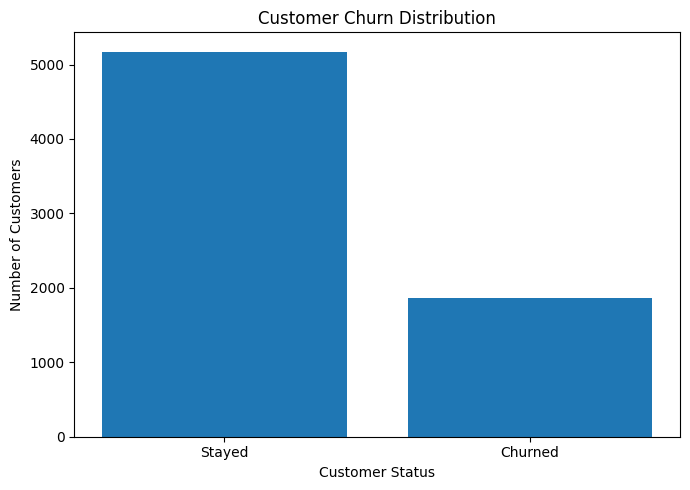

Churn distribution chart saved successfully!


In [5]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Stayed", "Churned"],
    [
        churn_counts.get(0, 0),
        churn_counts.get(1, 0)
    ]
)

plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.tight_layout()

plt.savefig(
    "../../Reports/week4/person3_customer_churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Churn distribution chart saved successfully!")

In [6]:
# Contract Type vs Churn

contract_churn = pd.crosstab(
    df["Contract_One year"] + df["Contract_Two year"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn          0          1
row_0                      
0      57.290323  42.709677
1      93.244949   6.755051


In [7]:
# Create contract category from encoded columns

df["Contract_Type"] = np.select(
    [
        df["Contract_Two year"] == 1,
        df["Contract_One year"] == 1
    ],
    [
        "Two year",
        "One year"
    ],
    default="Month-to-month"
)

contract_churn = (
    pd.crosstab(
        df["Contract_Type"],
        df["Churn"],
        normalize="index"
    ) * 100
)

print(contract_churn)

Churn                   0          1
Contract_Type                       
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


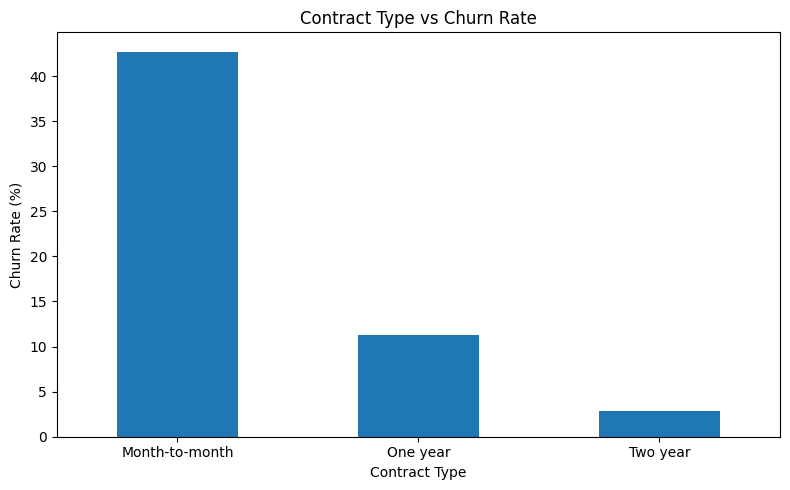

Contract vs Churn chart saved successfully!


In [8]:
plt.figure(figsize=(8, 5))

contract_churn[1].plot(kind="bar")

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.title("Contract Type vs Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "../../Reports/week4/person3_contract_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Contract vs Churn chart saved successfully!")

C:\Users\Acer\AppData\Local\Temp\ipykernel_27776\967509820.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


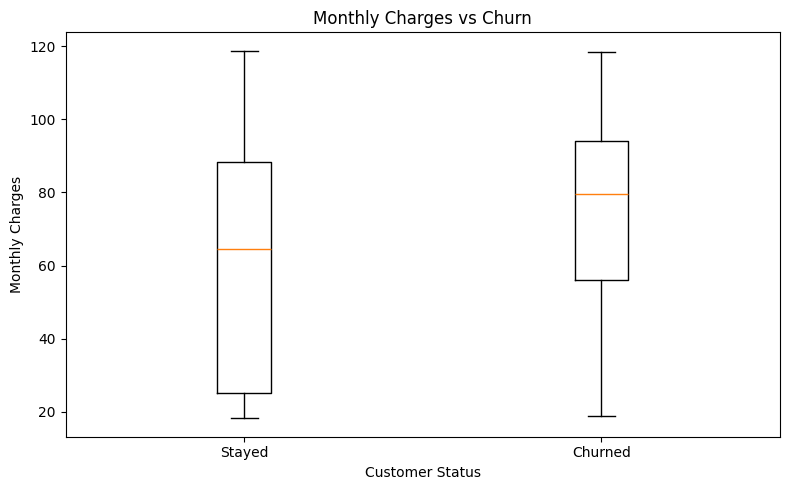

Monthly Charges vs Churn chart saved successfully!


In [9]:
# Monthly Charges vs Churn

churned = df[df["Churn"] == 1]["MonthlyCharges"]
stayed = df[df["Churn"] == 0]["MonthlyCharges"]

plt.figure(figsize=(8, 5))

plt.boxplot(
    [stayed, churned],
    labels=["Stayed", "Churned"]
)

plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges vs Churn")
plt.tight_layout()

plt.savefig(
    "../../Reports/week4/person3_monthly_charges_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Monthly Charges vs Churn chart saved successfully!")

Tenure vs Churn

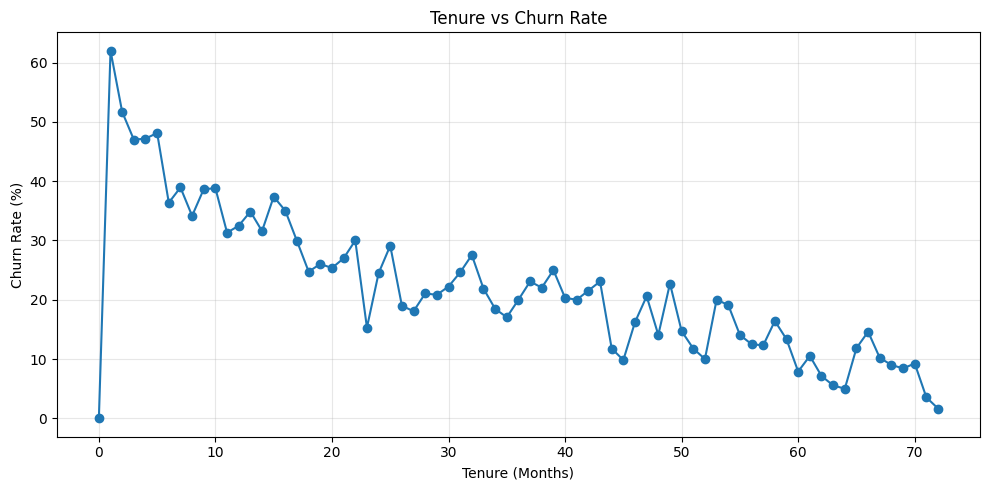

Tenure vs Churn chart saved successfully!


In [10]:
# Tenure vs Churn

tenure_churn = (
    df.groupby("tenure")["Churn"]
    .mean() * 100
)

plt.figure(figsize=(10, 5))

plt.plot(
    tenure_churn.index,
    tenure_churn.values,
    marker="o"
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")
plt.title("Tenure vs Churn Rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../../Reports/week4/person3_tenure_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Tenure vs Churn chart saved successfully!")

In [12]:
# Internet Service vs Churn

df["Internet_Service_Type"] = np.select(
    [
        df["InternetService_Fiber optic"] == 1,
        df["InternetService_No"] == 1
    ],
    [
        "Fiber optic",
        "No internet service"
    ],
    default="DSL"
)

internet_churn = (
    df.groupby("Internet_Service_Type")["Churn"]
    .mean() * 100
)

print("Internet Service vs Churn Rate:")
print(internet_churn)


Internet Service vs Churn Rate:
Internet_Service_Type
DSL                    18.959108
Fiber optic            41.892765
No internet service     7.404980
Name: Churn, dtype: float64


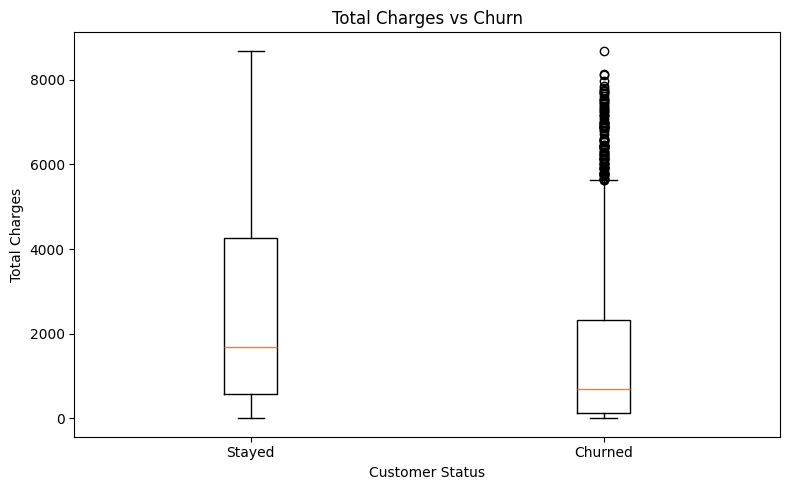

Total Charges vs Churn chart saved successfully!
Saved path: ../../Reports/week4/person3_total_charges_vs_churn.png


In [15]:
import matplotlib.pyplot as plt

# ==========================================
# Total Charges vs Churn
# ==========================================

# Separate TotalCharges based on Churn
churned_total = df[df["Churn"] == 1]["TotalCharges"]
stayed_total = df[df["Churn"] == 0]["TotalCharges"]

# Create figure
plt.figure(figsize=(8, 5))

# Boxplot
plt.boxplot(
    [stayed_total, churned_total],
    tick_labels=["Stayed", "Churned"]
)

# Labels and title
plt.xlabel("Customer Status")
plt.ylabel("Total Charges")
plt.title("Total Charges vs Churn")

plt.tight_layout()

# Save chart
chart_path = "../../Reports/week4/person3_total_charges_vs_churn.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

# Display chart
plt.show()

print("Total Charges vs Churn chart saved successfully!")
print("Saved path:", chart_path)

Payment Method vs Churn Rate:
Payment_Method_Type
Bank transfer       16.709845
Credit card         15.243101
Electronic check    45.285412
Mailed check        19.106700
Name: Churn, dtype: float64


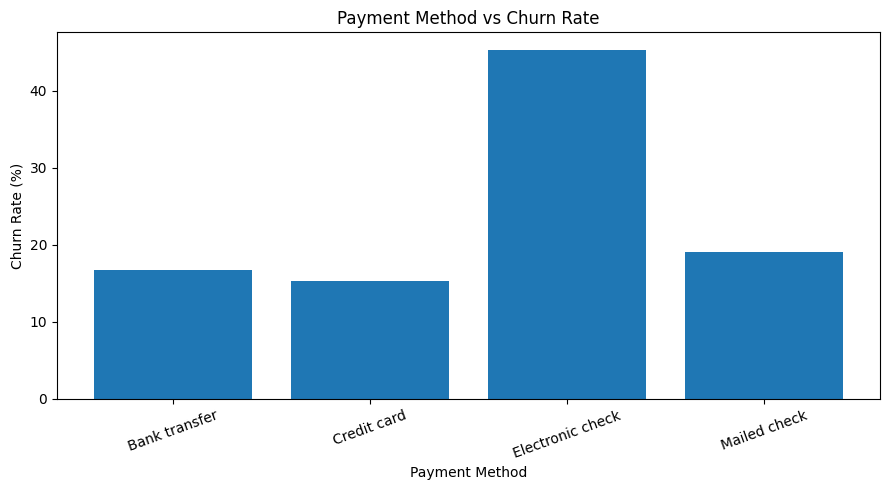

Payment Method vs Churn chart saved successfully!
Saved path: ../../Reports/week4/person3_payment_method_vs_churn.png


In [16]:
import matplotlib.pyplot as plt

# ==========================================
# Payment Method vs Churn
# ==========================================

# Create payment method category
df["Payment_Method_Type"] = np.select(
    [
        df["PaymentMethod_Electronic check"] == 1,
        df["PaymentMethod_Credit card (automatic)"] == 1,
        df["PaymentMethod_Mailed check"] == 1
    ],
    [
        "Electronic check",
        "Credit card",
        "Mailed check"
    ],
    default="Bank transfer"
)

# Calculate churn rate
payment_churn = (
    df.groupby("Payment_Method_Type")["Churn"]
    .mean() * 100
)

print("Payment Method vs Churn Rate:")
print(payment_churn)

# Create chart
plt.figure(figsize=(9, 5))

plt.bar(
    payment_churn.index,
    payment_churn.values
)

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.title("Payment Method vs Churn Rate")
plt.xticks(rotation=20)
plt.tight_layout()

# Save chart
chart_path = "../../Reports/week4/person3_payment_method_vs_churn.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Payment Method vs Churn chart saved successfully!")
print("Saved path:", chart_path)

Senior Citizen vs Churn Rate:
SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: float64


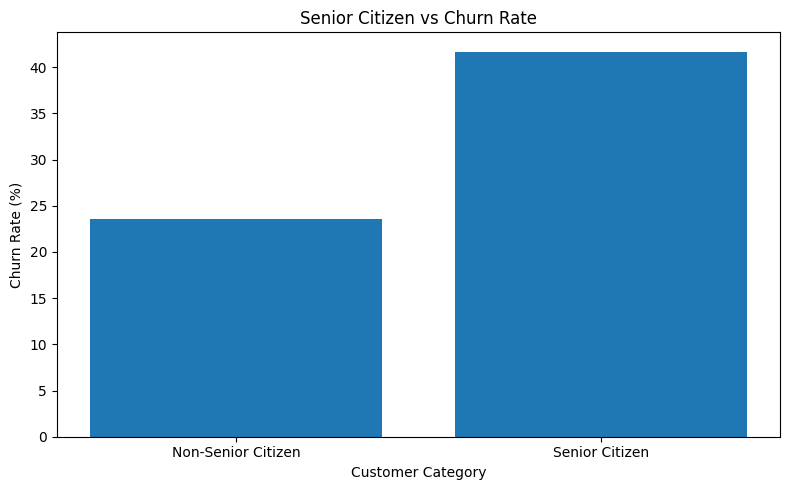

Senior Citizen vs Churn chart saved successfully!
Saved path: ../../Reports/week4/person3_senior_citizen_vs_churn.png


In [17]:
import matplotlib.pyplot as plt

# ==========================================
# Senior Citizen vs Churn
# ==========================================

# Calculate churn rate
senior_churn = (
    df.groupby("SeniorCitizen")["Churn"]
    .mean() * 100
)

print("Senior Citizen vs Churn Rate:")
print(senior_churn)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["Non-Senior Citizen", "Senior Citizen"],
    [
        senior_churn.get(0, 0),
        senior_churn.get(1, 0)
    ]
)

plt.xlabel("Customer Category")
plt.ylabel("Churn Rate (%)")
plt.title("Senior Citizen vs Churn Rate")
plt.tight_layout()

# Save chart
chart_path = "../../Reports/week4/person3_senior_citizen_vs_churn.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Senior Citizen vs Churn chart saved successfully!")
print("Saved path:", chart_path)

Partner vs Churn

Partner vs Churn Rate:
Partner_Yes
0    32.957979
1    19.664903
Name: Churn, dtype: float64


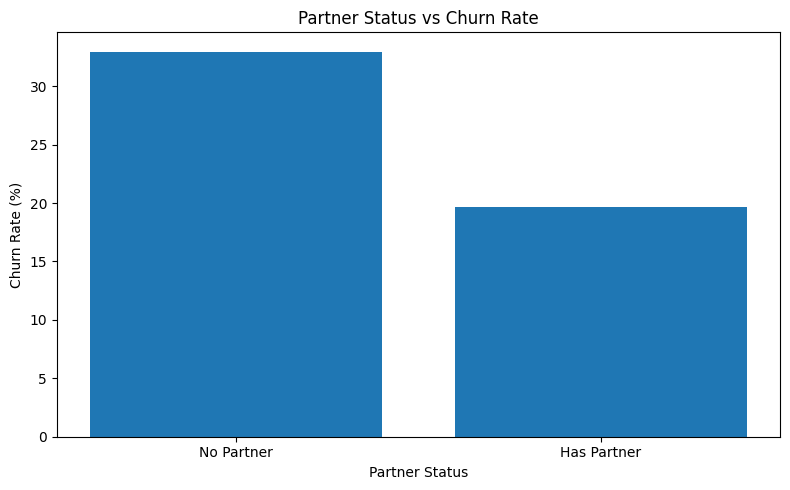

Partner vs Churn chart saved successfully!
Saved path: ../../Reports/week4/person3_partner_vs_churn.png


In [18]:
import matplotlib.pyplot as plt

# ==========================================
# Partner vs Churn
# ==========================================

partner_churn = (
    df.groupby("Partner_Yes")["Churn"]
    .mean() * 100
)

print("Partner vs Churn Rate:")
print(partner_churn)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Partner", "Has Partner"],
    [
        partner_churn.get(0, 0),
        partner_churn.get(1, 0)
    ]
)

plt.xlabel("Partner Status")
plt.ylabel("Churn Rate (%)")
plt.title("Partner Status vs Churn Rate")
plt.tight_layout()

# Save chart
chart_path = "../../Reports/week4/person3_partner_vs_churn.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Partner vs Churn chart saved successfully!")
print("Saved path:", chart_path)

Dependents vs Churn

Dependents vs Churn Rate:
Dependents_Yes
0    31.279140
1    15.450237
Name: Churn, dtype: float64


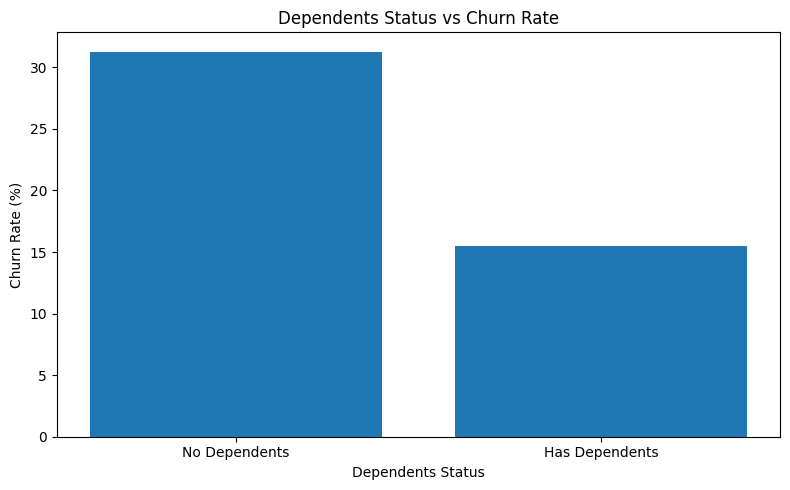

Dependents vs Churn chart saved successfully!
Saved path: ../../Reports/week4/person3_dependents_vs_churn.png


In [19]:
import matplotlib.pyplot as plt

# ==========================================
# Dependents vs Churn
# ==========================================

dependents_churn = (
    df.groupby("Dependents_Yes")["Churn"]
    .mean() * 100
)

print("Dependents vs Churn Rate:")
print(dependents_churn)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Dependents", "Has Dependents"],
    [
        dependents_churn.get(0, 0),
        dependents_churn.get(1, 0)
    ]
)

plt.xlabel("Dependents Status")
plt.ylabel("Churn Rate (%)")
plt.title("Dependents Status vs Churn Rate")
plt.tight_layout()

# Save chart
chart_path = "../../Reports/week4/person3_dependents_vs_churn.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Dependents vs Churn chart saved successfully!")
print("Saved path:", chart_path)

Phone Service vs Churn

Phone Service vs Churn Rate:
PhoneService_Yes
0    24.926686
1    26.709637
Name: Churn, dtype: float64


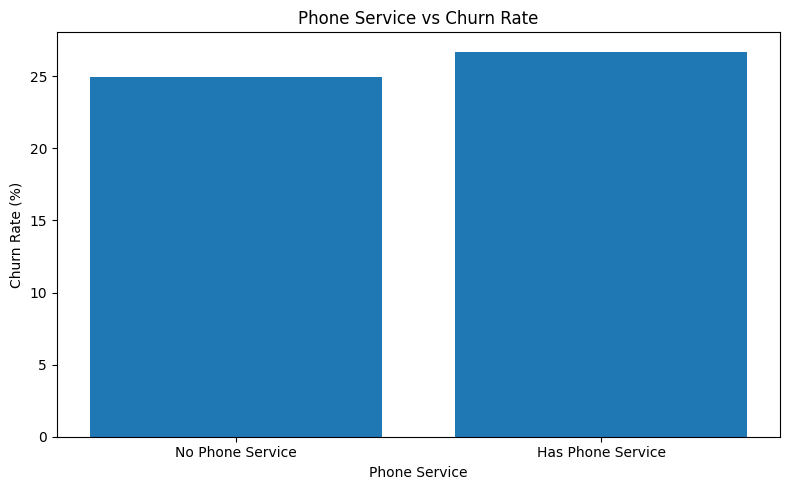

Phone Service vs Churn chart saved successfully!
Saved path: ../../Reports/week4/person3_phone_service_vs_churn.png


In [20]:
import matplotlib.pyplot as plt

# ==========================================
# Phone Service vs Churn
# ==========================================

phone_churn = (
    df.groupby("PhoneService_Yes")["Churn"]
    .mean() * 100
)

print("Phone Service vs Churn Rate:")
print(phone_churn)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Phone Service", "Has Phone Service"],
    [
        phone_churn.get(0, 0),
        phone_churn.get(1, 0)
    ]
)

plt.xlabel("Phone Service")
plt.ylabel("Churn Rate (%)")
plt.title("Phone Service vs Churn Rate")
plt.tight_layout()

# Save chart
chart_path = "../../Reports/week4/person3_phone_service_vs_churn.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Phone Service vs Churn chart saved successfully!")
print("Saved path:", chart_path)

Online Security vs Churn

Online Security vs Churn Rate:
OnlineSecurity_Yes
0    31.329618
1    14.611194
Name: Churn, dtype: float64


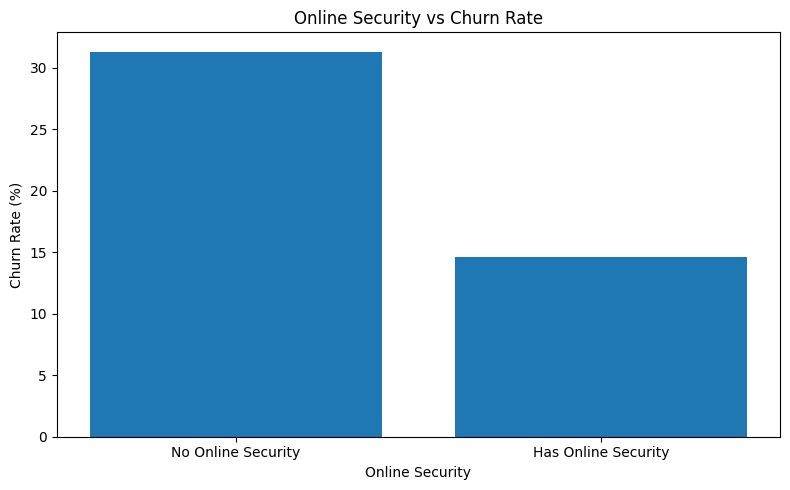

Online Security vs Churn chart saved successfully!
Saved path: ../../Reports/week4/person3_online_security_vs_churn.png


In [21]:
import matplotlib.pyplot as plt

# ==========================================
# Online Security vs Churn
# ==========================================

security_churn = (
    df.groupby("OnlineSecurity_Yes")["Churn"]
    .mean() * 100
)

print("Online Security vs Churn Rate:")
print(security_churn)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Online Security", "Has Online Security"],
    [
        security_churn.get(0, 0),
        security_churn.get(1, 0)
    ]
)

plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.title("Online Security vs Churn Rate")
plt.tight_layout()

# Save chart
chart_path = "../../Reports/week4/person3_online_security_vs_churn.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Online Security vs Churn chart saved successfully!")
print("Saved path:", chart_path)

Online Backup vs Churn

Online Backup vs Churn Rate:
OnlineBackup_Yes
0    29.172085
1    21.531494
Name: Churn, dtype: float64


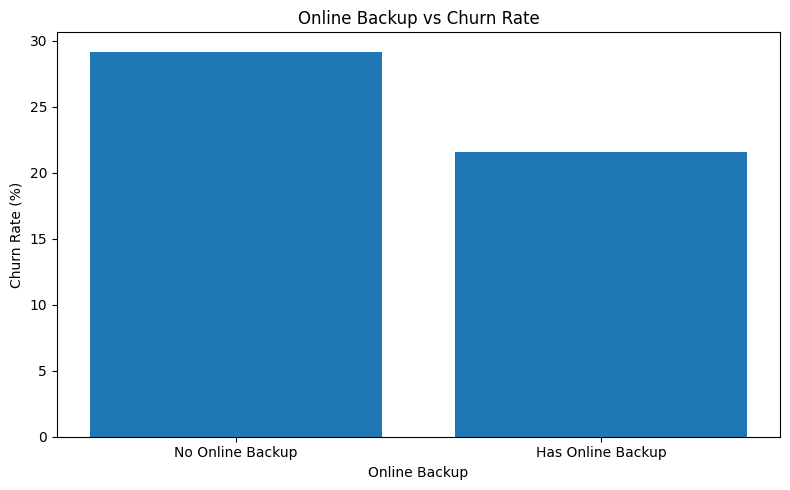

Online Backup vs Churn chart saved successfully!
Saved path: ../../Reports/week4/person3_online_backup_vs_churn.png


In [22]:
import matplotlib.pyplot as plt

# ==========================================
# Online Backup vs Churn
# ==========================================

backup_churn = (
    df.groupby("OnlineBackup_Yes")["Churn"]
    .mean() * 100
)

print("Online Backup vs Churn Rate:")
print(backup_churn)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Online Backup", "Has Online Backup"],
    [
        backup_churn.get(0, 0),
        backup_churn.get(1, 0)
    ]
)

plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")
plt.title("Online Backup vs Churn Rate")
plt.tight_layout()

# Save chart
chart_path = "../../Reports/week4/person3_online_backup_vs_churn.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Online Backup vs Churn chart saved successfully!")
print("Saved path:", chart_path)

Device Protection vs Churn

Device Protection vs Churn Rate:
DeviceProtection_Yes
0    28.651807
1    22.502064
Name: Churn, dtype: float64


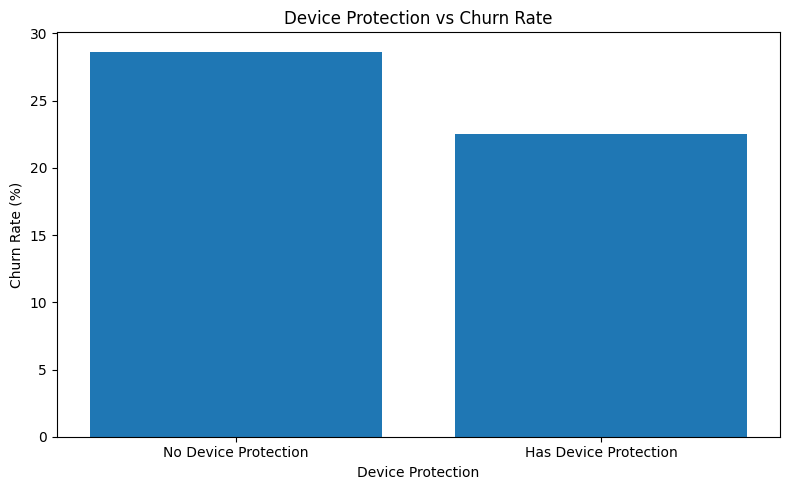

Device Protection vs Churn chart saved successfully!
Saved path: ../../Reports/week4/person3_device_protection_vs_churn.png


In [23]:
import matplotlib.pyplot as plt

# ==========================================
# Device Protection vs Churn
# ==========================================

device_churn = (
    df.groupby("DeviceProtection_Yes")["Churn"]
    .mean() * 100
)

print("Device Protection vs Churn Rate:")
print(device_churn)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Device Protection", "Has Device Protection"],
    [
        device_churn.get(0, 0),
        device_churn.get(1, 0)
    ]
)

plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")
plt.title("Device Protection vs Churn Rate")
plt.tight_layout()

# Save chart
chart_path = "../../Reports/week4/person3_device_protection_vs_churn.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Device Protection vs Churn chart saved successfully!")
print("Saved path:", chart_path)

Tech Support vs Churn

Tech Support vs Churn Rate:
TechSupport_Yes
0    31.186237
1    15.166341
Name: Churn, dtype: float64


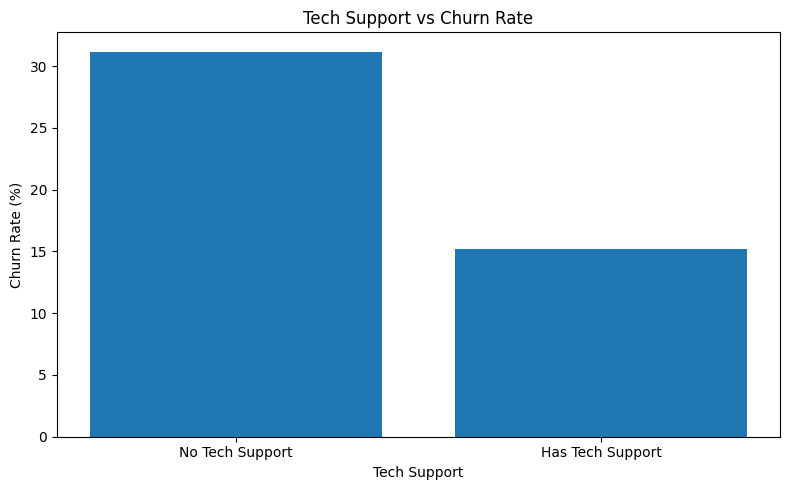

Tech Support vs Churn chart saved successfully!
Saved path: ../../Reports/week4/person3_tech_support_vs_churn.png


In [24]:
import matplotlib.pyplot as plt

# ==========================================
# Tech Support vs Churn
# ==========================================

tech_support_churn = (
    df.groupby("TechSupport_Yes")["Churn"]
    .mean() * 100
)

print("Tech Support vs Churn Rate:")
print(tech_support_churn)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Tech Support", "Has Tech Support"],
    [
        tech_support_churn.get(0, 0),
        tech_support_churn.get(1, 0)
    ]
)

plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.title("Tech Support vs Churn Rate")
plt.tight_layout()

# Save chart
chart_path = "../../Reports/week4/person3_tech_support_vs_churn.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Tech Support vs Churn chart saved successfully!")
print("Saved path:", chart_path)

Streaming TV vs Churn

Streaming TV vs Churn Rate:
StreamingTV_Yes
0    24.331181
1    30.070188
Name: Churn, dtype: float64


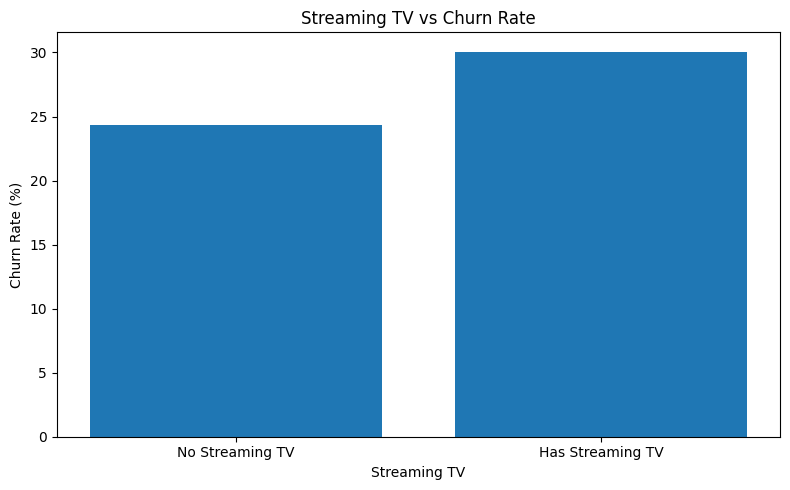

Streaming TV vs Churn chart saved successfully!
Saved path: ../../Reports/week4/person3_streaming_tv_vs_churn.png


In [25]:
import matplotlib.pyplot as plt

# ==========================================
# Streaming TV vs Churn
# ==========================================

streaming_tv_churn = (
    df.groupby("StreamingTV_Yes")["Churn"]
    .mean() * 100
)

print("Streaming TV vs Churn Rate:")
print(streaming_tv_churn)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Streaming TV", "Has Streaming TV"],
    [
        streaming_tv_churn.get(0, 0),
        streaming_tv_churn.get(1, 0)
    ]
)

plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")
plt.title("Streaming TV vs Churn Rate")
plt.tight_layout()

# Save chart
chart_path = "../../Reports/week4/person3_streaming_tv_vs_churn.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Streaming TV vs Churn chart saved successfully!")
print("Saved path:", chart_path)

Streaming Movies vs Churn

Streaming Movies vs Churn Rate:
StreamingMovies_Yes
0    24.379494
1    29.941435
Name: Churn, dtype: float64


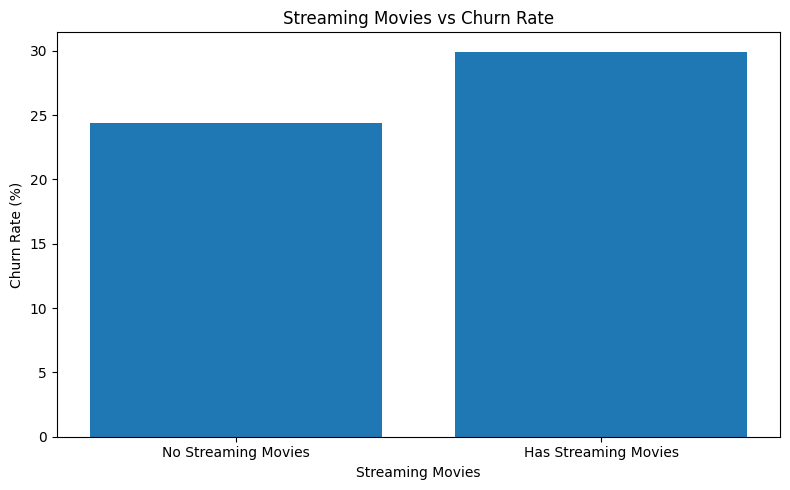

Streaming Movies vs Churn chart saved successfully!
Saved path: ../../Reports/week4/person3_streaming_movies_vs_churn.png


In [26]:
import matplotlib.pyplot as plt

# ==========================================
# Streaming Movies vs Churn
# ==========================================

streaming_movies_churn = (
    df.groupby("StreamingMovies_Yes")["Churn"]
    .mean() * 100
)

print("Streaming Movies vs Churn Rate:")
print(streaming_movies_churn)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Streaming Movies", "Has Streaming Movies"],
    [
        streaming_movies_churn.get(0, 0),
        streaming_movies_churn.get(1, 0)
    ]
)

plt.xlabel("Streaming Movies")
plt.ylabel("Churn Rate (%)")
plt.title("Streaming Movies vs Churn Rate")
plt.tight_layout()

# Save chart
chart_path = "../../Reports/week4/person3_streaming_movies_vs_churn.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Streaming Movies vs Churn chart saved successfully!")
print("Saved path:", chart_path)

Paperless Billing vs Churn

Paperless Billing vs Churn Rate:
PaperlessBilling_Yes
0    16.330084
1    33.565092
Name: Churn, dtype: float64


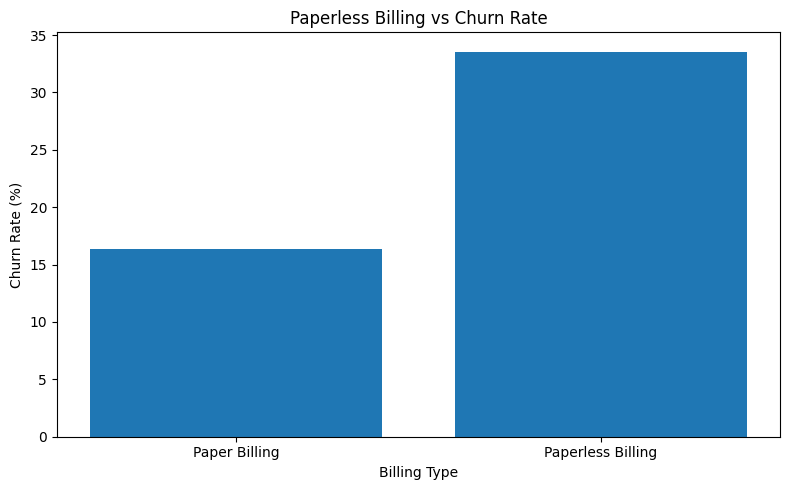

Paperless Billing vs Churn chart saved successfully!
Saved path: ../../Reports/week4/person3_paperless_billing_vs_churn.png


In [27]:
import matplotlib.pyplot as plt

# ==========================================
# Paperless Billing vs Churn
# ==========================================

paperless_churn = (
    df.groupby("PaperlessBilling_Yes")["Churn"]
    .mean() * 100
)

print("Paperless Billing vs Churn Rate:")
print(paperless_churn)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    ["Paper Billing", "Paperless Billing"],
    [
        paperless_churn.get(0, 0),
        paperless_churn.get(1, 0)
    ]
)

plt.xlabel("Billing Type")
plt.ylabel("Churn Rate (%)")
plt.title("Paperless Billing vs Churn Rate")
plt.tight_layout()

# Save chart
chart_path = "../../Reports/week4/person3_paperless_billing_vs_churn.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Paperless Billing vs Churn chart saved successfully!")
print("Saved path:", chart_path)

In [28]:
# ==========================================
# WEEK 4 - FINAL BUSINESS CHURN SUMMARY
# ==========================================

import os
import pandas as pd

report_dir = "../../Reports/week4"
os.makedirs(report_dir, exist_ok=True)

# Overall metrics
total_customers = len(df)
churned_customers = int(df["Churn"].sum())
churn_rate = df["Churn"].mean() * 100
avg_monthly_charges = df["MonthlyCharges"].mean()
avg_tenure = df["tenure"].mean()

# Summary table
summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Overall Churn Rate (%)",
        "Average Monthly Charges",
        "Average Tenure (Months)"
    ],
    "Value": [
        total_customers,
        churned_customers,
        round(churn_rate, 2),
        round(avg_monthly_charges, 2),
        round(avg_tenure, 2)
    ]
})

print("===== WEEK 4 BUSINESS CHURN SUMMARY =====")
print(summary.to_string(index=False))

# Save CSV
summary.to_csv(
    f"{report_dir}/person3_week4_business_summary.csv",
    index=False
)

# Create Markdown report
report = f"""# Week 4 Business Churn Analysis

## Overall Customer Metrics

- **Total Customers:** {total_customers}
- **Churned Customers:** {churned_customers}
- **Overall Churn Rate:** {churn_rate:.2f}%
- **Average Monthly Charges:** {avg_monthly_charges:.2f}
- **Average Tenure:** {avg_tenure:.2f} months

## Analysis Areas

The Week 4 analysis covers:

1. Customer Churn Distribution
2. Contract Type vs Churn
3. Monthly Charges vs Churn
4. Tenure vs Churn
5. Internet Service vs Churn
6. Total Charges vs Churn
7. Payment Method vs Churn
8. Senior Citizen vs Churn
9. Partner vs Churn
10. Dependents vs Churn
11. Phone Service vs Churn
12. Online Security vs Churn
13. Online Backup vs Churn
14. Device Protection vs Churn
15. Tech Support vs Churn
16. Streaming TV vs Churn
17. Streaming Movies vs Churn
18. Paperless Billing vs Churn

## Business Objective

Identify customer segments with higher churn risk and understand
the major service, contract, billing, and customer characteristics
associated with customer churn.

## Deliverables

All Week 4 visualizations are saved in the `Reports/week4` directory.
"""

with open(
    f"{report_dir}/person3_week4_business_churn_report.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(report)

print("\nWeek 4 summary CSV saved successfully!")
print("Week 4 Markdown report saved successfully!")

===== WEEK 4 BUSINESS CHURN SUMMARY =====
                 Metric   Value
        Total Customers 7043.00
      Churned Customers 1869.00
 Overall Churn Rate (%)   26.54
Average Monthly Charges   64.76
Average Tenure (Months)   32.37

Week 4 summary CSV saved successfully!
Week 4 Markdown report saved successfully!
